1. **Libraries and Dataset Loading**: The code imports necessary libraries (`numpy`, `pandas`, `matplotlib`) and loads a CSV dataset named `data.csv`.  
2. **Data Cleaning**: It removes the columns `"id"` and `"Unnamed: 32"` from the dataset to retain only relevant features.  
3. **Feature and Label Preparation**: The features (for clustering) are extracted by removing the `"diagnosis"` column, and labels are mapped to binary values (`1` for malignant, `0` for benign).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('data.csv')

# Preprocess data
data = data.drop(["id", "Unnamed: 32"], axis=1)  # Drop unnecessary columns
features = data.drop(["diagnosis"], axis=1).values  # Drop labels for clustering
labels = data["diagnosis"].map({"M": 1, "B": 0}).values  # Optional: For later comparison


1. **Function Setup**: The `k_means` function implements the K-Means clustering algorithm, initializing `k` random centroids and iterating to refine them up to `max_iters` times.  
2. **Clustering Logic**: At each iteration, it assigns data points to the nearest centroid using Euclidean distance and recalculates centroids as the mean of assigned points.  
3. **Testing**: The function is tested with `k=2` to cluster the `features` dataset, returning the cluster assignments and final centroids.

In [3]:
def k_means(data, k, max_iters=100):
    n_samples, n_features = data.shape
    centroids = data[np.random.choice(n_samples, k, replace=False)]  # Random initialization
    for _ in range(max_iters):
        # Assign clusters
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        clusters = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = np.array([data[clusters == i].mean(axis=0) for i in range(k)])
        
        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return clusters, centroids

# Test K-Means with k=2
clusters, centroids = k_means(features, k=2)



1. **Standardization**: The `pca` function standardizes the dataset by subtracting the mean and dividing by the standard deviation of each feature.  
2. **PCA Process**: It calculates the covariance matrix, performs eigen decomposition to get eigenvalues and eigenvectors, and selects the top `n_components` principal components.  
3. **Dimensionality Reduction**: The standardized data is projected onto the principal components, reducing its dimensionality to `n_components`, which is tested with `n_components=2`.

In [4]:
def pca(data, n_components):
    # Standardize the dataset
    data_mean = np.mean(data, axis=0)
    data_std = np.std(data, axis=0)
    standardized_data = (data - data_mean) / data_std
    
    # Compute covariance matrix
    covariance_matrix = np.cov(standardized_data.T)
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
    
    # Select top n_components
    idx = np.argsort(-eigenvalues)  # Sort eigenvalues in descending order
    principal_components = eigenvectors[:, idx[:n_components]]
    
    # Project data onto principal components
    reduced_data = np.dot(standardized_data, principal_components)
    return reduced_data

# Test PCA with 2 components
reduced_features = pca(features, n_components=2)


Evaluation Metrics: To quantitatively compare the clustering with the original labels:
Adjusted Rand Index (ARI)
Normalized Mutual Information (NMI)
Homogeneity, Completeness, and V-Measure

In [5]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
def evaluate_clustering(true_labels, predicted_labels):
    """Evaluate clustering results against true labels."""
#Measures the mutual dependence between the true labels and predicted clusters, normalized to ensure comparability across different clusterings.
    nmi = normalized_mutual_info_score(true_labels, predicted_labels)
#Measures the similarity between the true labels and predicted clusters, adjusted for chance.
    ari = adjusted_rand_score(true_labels, predicted_labels)  
#Measures whether each cluster contains only members of a single class.

    homogeneity = homogeneity_score(true_labels, predicted_labels)
#Measures whether all members of a given class are assigned to the same cluster.
    completeness = completeness_score(true_labels, predicted_labels)
#The harmonic mean of homogeneity and completeness, providing a balanced measure.
    v_measure = v_measure_score(true_labels, predicted_labels)
    
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
    print(f"Homogeneity: {homogeneity:.4f}")
    print(f"Completeness: {completeness:.4f}")
    print(f"V-Measure: {v_measure:.4f}")

1. **Elbow Method Calculation**: The `elbow_method` function calculates the Sum of Squared Errors (SSE) for `k` clusters ranging from 1 to `max_k` using the `k_means` function.  
2. **Plotting SSE vs. k**: SSE values are stored and plotted against the number of clusters (`k`) to visualize the "elbow point," which suggests the optimal number of clusters.  
3. **Test on Features**: The method is applied to the `features` dataset, with `k` ranging from 1 to 10, and the results are displayed using a line plot.

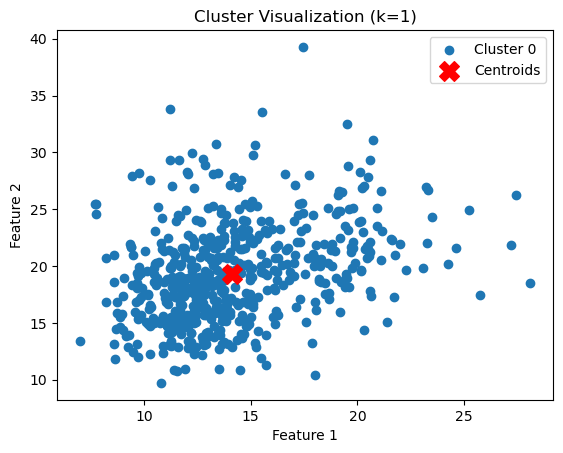

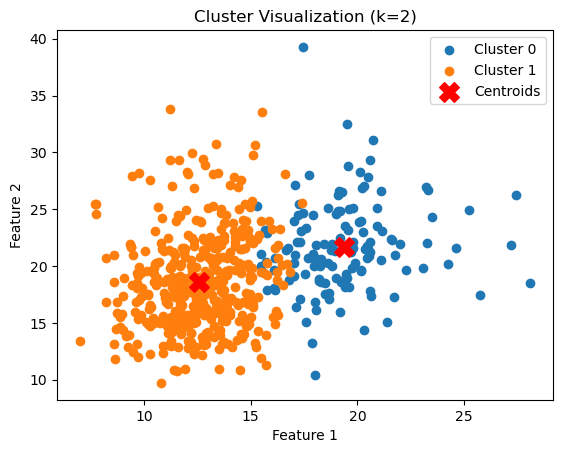

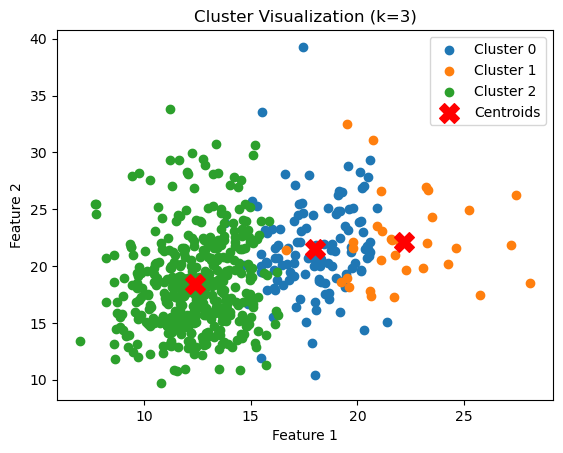

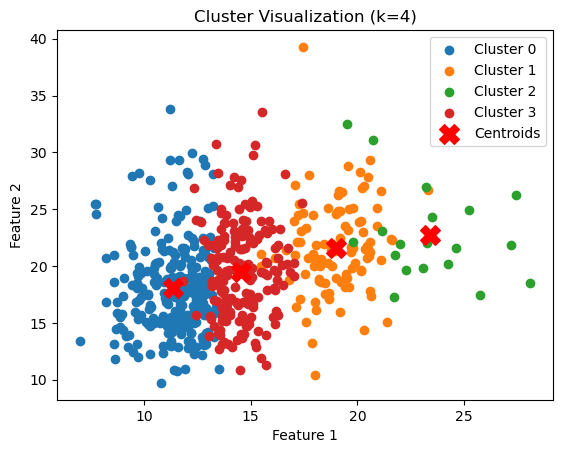

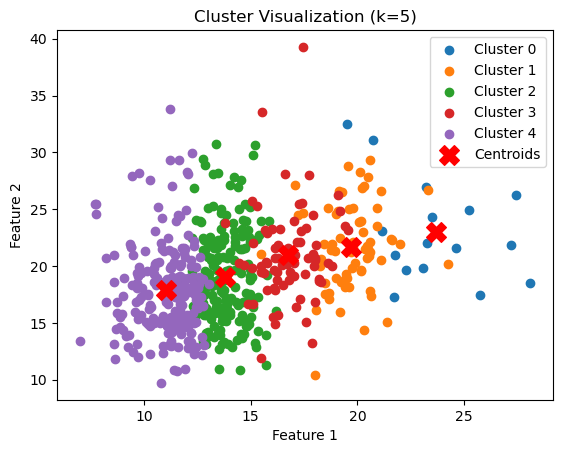

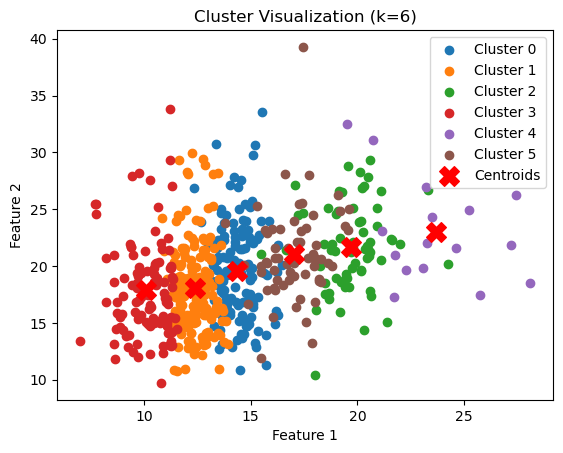

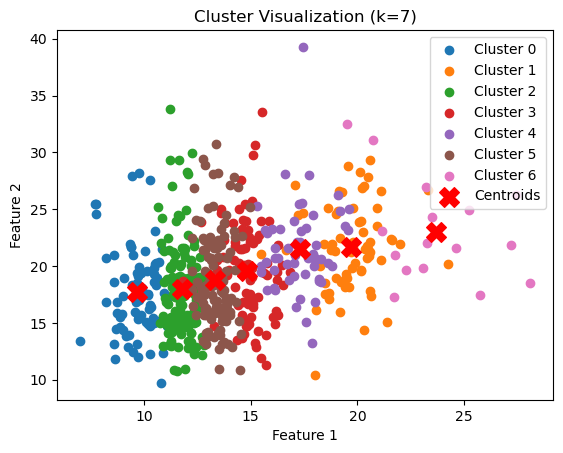

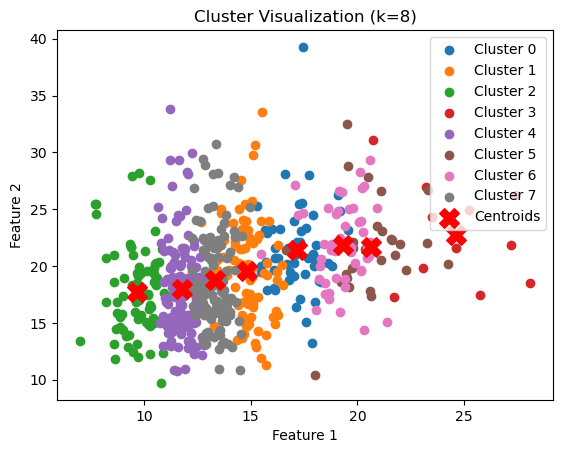

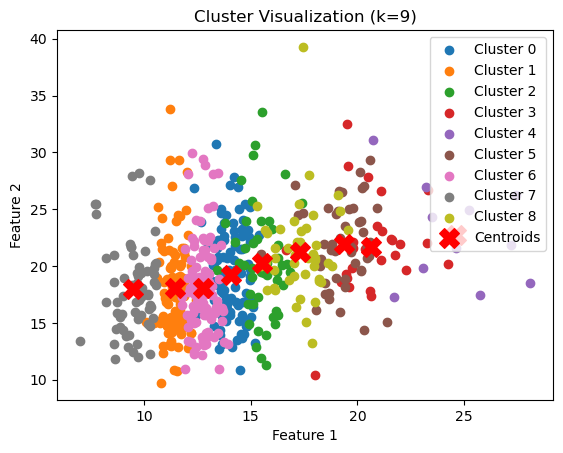

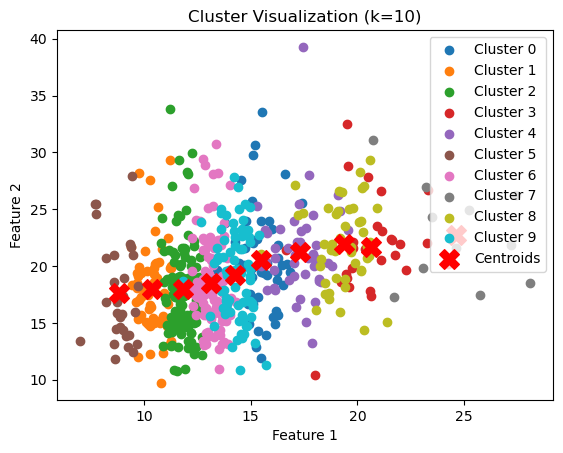

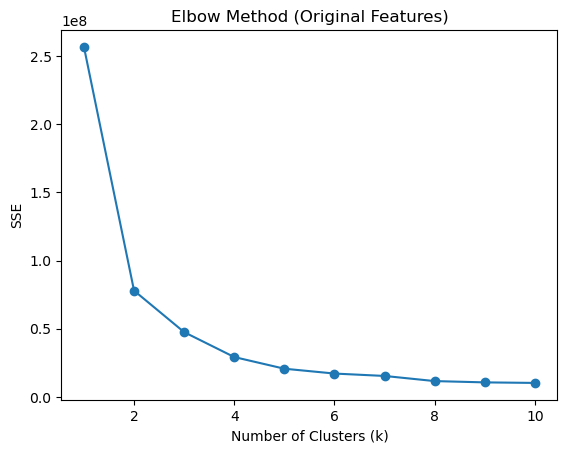

In [6]:
def visualize_clusters(data, k, labels, centroids):
    """Visualize clusters for the given k."""
    plt.figure()
    for cluster_id in range(k):
        cluster_points = data[labels == cluster_id]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")
    plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.title(f"Cluster Visualization (k={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()
def elbow_and_visualize(data, max_k=10, plot_clusters=True,plot_elbow=True):
    sse = []
    for k in range(1, max_k + 1):
        # Perform k-means clustering
        clusters, centroids = k_means(data, k)
        
        # Compute SSE
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        sse.append(np.sum(np.min(distances, axis=1) ** 2))
        
        # Visualize clusters
        if plot_clusters : 
            visualize_clusters(data, k, clusters, centroids)
    
    if plot_elbow:
         # Elbow plot
         plt.plot(range(1, max_k + 1), sse, marker='o')
         plt.title("Elbow Method (Original Features)")
         plt.xlabel("Number of Clusters (k)")
         plt.ylabel("SSE")
         plt.show()
    
    return sse

# Run elbow method and visualize clusters
x=elbow_and_visualize(features, max_k=10)

1. **Experiment Setup**: The code applies PCA to reduce the dataset's dimensions to `[1, 2, 5, 10]` components, then calculates SSE values for different cluster numbers (`k`) using the `elbow_method`.  
2. **SSE Comparison**: SSE results for each PCA-reduced dataset are stored and plotted against the number of clusters to evaluate clustering performance at varying dimensionalities.  
3. **Visualization**: The SSE plots for each PCA-reduced dataset are overlaid with labels indicating the number of PCA components, helping identify the impact of dimensionality on clustering.

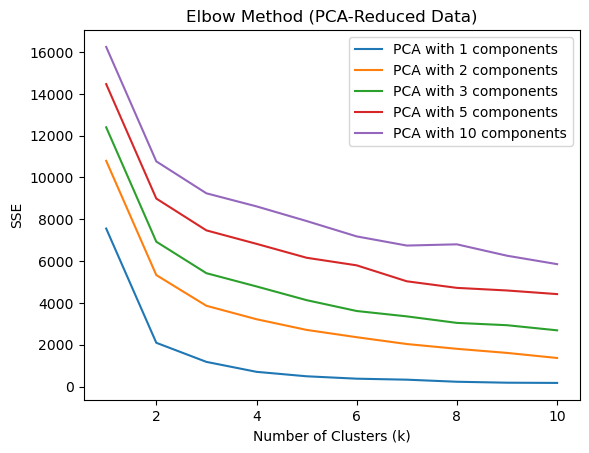

In [19]:
# Second experiment with PCA-reduced data
sse_pca = []
pca_components = [1, 2, 3,5, 10]  # Number of PCA components to try

for n_components in pca_components:
    reduced_data = pca(features, n_components)  # Perform PCA
    sse = elbow_and_visualize(reduced_data, max_k=10, plot_clusters=False,plot_elbow=False)  # Elbow method without cluster visualization
    sse_pca.append(sse)

# Plot SSE for different PCA dimensions
for idx, (n_components, sse) in enumerate(zip(pca_components, sse_pca)):
    plt.plot(range(1, 11), sse, label=f"PCA with {n_components} components")
plt.title("Elbow Method (PCA-Reduced Data)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.legend()
plt.show()




In [18]:
# Create a DataFrame for SSE values
sse_table = pd.DataFrame(
    data=np.array(sse_pca).T,  # Transpose to make k the rows and components the columns
    columns=[f"PCA {n_components} Components" for n_components in pca_components],
    index=range(1, len(sse_pca[0]) + 1)  # Index corresponds to number of clusters (k)
)

# Add an index name for clarity
sse_table.index.name = "Number of Clusters (k)"

# Display the table
print(sse_table)

                        PCA 1 Components  PCA 2 Components  PCA 3 Components  \
Number of Clusters (k)                                                         
1                            7557.234771      10795.615546      12399.028514   
2                            2094.601319       5332.555574       6928.438977   
3                            1181.541343       3865.463331       5428.947344   
4                             705.830261       3133.958099       4766.646690   
5                             492.551610       2518.962925       4129.844513   
6                             377.940293       2206.543544       3650.445292   
7                             330.486674       1965.710650       3235.983754   
8                             212.325317       1823.595116       3112.841034   
9                             186.126826       1588.379325       2843.383048   
10                            145.179121       1496.657916       2711.095720   

                        PCA 5 Component

kmean without pca

1. **Feature Selection and Clustering**: Two features (`feature_1` and `feature_2`) are selected for visualization, and K-Means clustering is applied to the dataset with `k=2`.  
2. **Scatter Plot**: A scatter plot is created to display data points based on the two selected features, color-coded by their assigned clusters.  
3. **Centroid Highlighting**: Cluster centroids are plotted as red "X" markers, with appropriate labels, to visualize their positions relative to the data points.

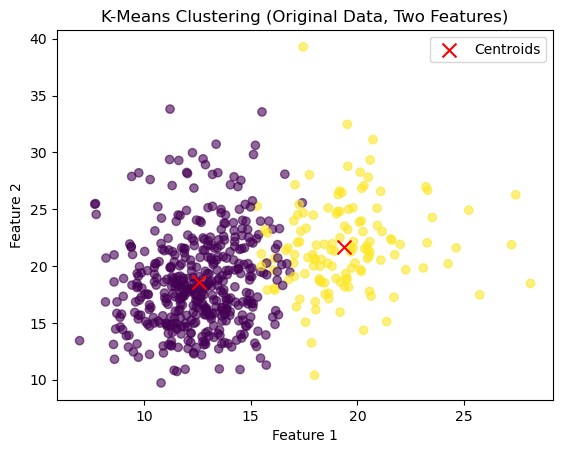

In [8]:
# Select two features for visualization
feature_1 = 0  # First feature (e.g., mean radius)
feature_2 = 1  # Second feature (e.g., mean texture)

clusters_original, centroids = k_means(features, k=2)  # Run K-Means with k=2

# Scatter plot for the two selected features
plt.scatter(features[:, feature_1], features[:, feature_2], c=clusters_original, cmap="viridis", alpha=0.6)
plt.scatter(centroids[:, feature_1], centroids[:, feature_2], c="red", marker="x", s=100, label="Centroids")
plt.title("K-Means Clustering (Original Data, Two Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


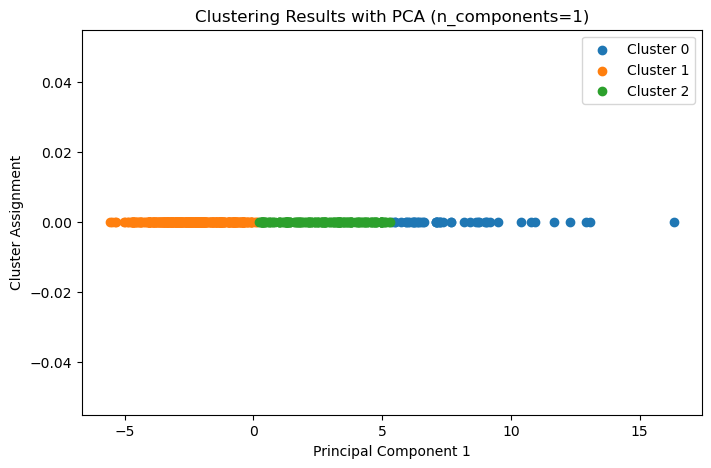

Adjusted Rand Index (ARI): 0.6288
Normalized Mutual Information (NMI): 0.5072
Homogeneity: 0.5872
Completeness: 0.4464
V-Measure: 0.5072


In [9]:
# Reduce data to 1D with PCA
n_components = 1
reduced_data = pca(features, n_components)

# Perform clustering
k = 3  # Number of clusters
predicted_clusters, centroids = k_means(reduced_data, k)

# Visualize results in 1D
plt.figure(figsize=(8, 5))
for cluster in np.unique(predicted_clusters):
    cluster_points = reduced_data[predicted_clusters == cluster]
    plt.scatter(cluster_points[:, 0], [0] * len(cluster_points), label=f"Cluster {cluster}")
plt.title(f"Clustering Results with PCA (n_components={n_components})")
plt.xlabel("Principal Component 1")
plt.ylabel("Cluster Assignment")
plt.legend()
plt.show()

# Evaluate clustering
evaluate_clustering(labels, predicted_clusters)


kmean with pca

1. **PCA Application**: The dataset is reduced to `best_n_components` (assumed to be 2) using PCA, capturing the most significant variance in the data.  
2. **Clustering on Reduced Data**: K-Means clustering is performed on the PCA-reduced features with `k=2` clusters, obtaining cluster assignments and centroids.  
3. **Visualization**: A scatter plot visualizes the clusters in the 2D PCA space, with data points color-coded by cluster and centroids marked as red "X" symbols.

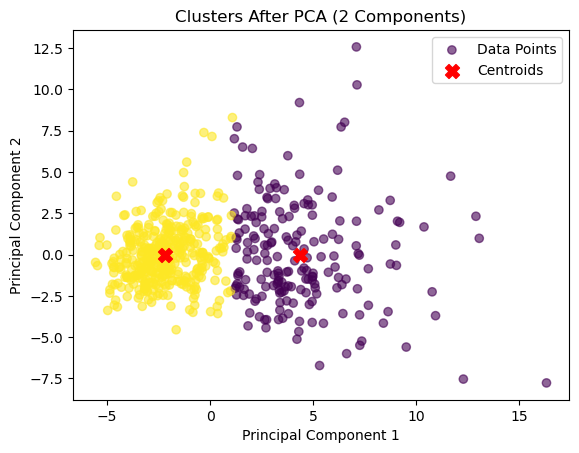

In [ ]:
#2 components were determined to be the best

best_n_components = 2 
# PCA with the best number of components
reduced_features = pca(features, best_n_components)

clusters_pca, centroids = k_means(reduced_features, k=2)


plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters_pca, cmap="viridis", alpha=0.6, label="Data Points")
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=100, label="Centroids")
plt.title(f"Clusters After PCA ({best_n_components} Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


true labels original features

1. **Scatter Plot of Original Labels**: The code plots data points using the first two features, with colors representing the true labels (`0` for benign, `1` for malignant).  
2. **Visualization Details**: It adds a color bar to indicate the mapping of colors to labels and sets axis labels and a title for better understanding.  
3. **Display**: The plot visually shows the distribution of the original labels in the feature space for comparison with clustering results.

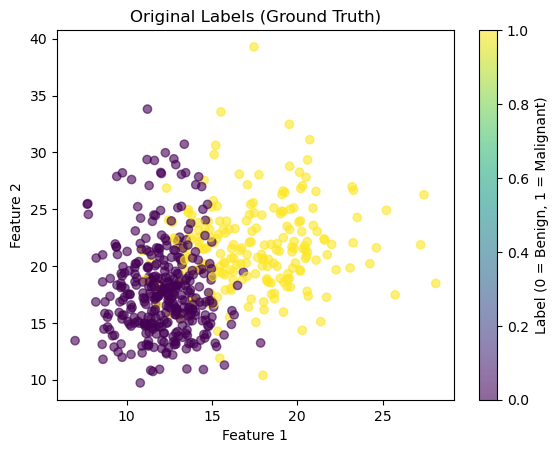

In [11]:
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap="viridis", alpha=0.6)
plt.title("Original Labels (Ground Truth)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Label (0 = Benign, 1 = Malignant)")
plt.show()


true labels reduced feature

1. **Scatter Plot of PCA-Reduced Data**: The code visualizes the PCA-reduced data (2 components), color-coding data points based on the true labels (`0` for benign, `1` for malignant).  
2. **Visualization Details**: It includes axis labels, a title, and a color bar to indicate the mapping of colors to the labels.  
3. **Purpose**: This plot helps compare the ground truth distribution in the PCA-reduced feature space to clustering results.

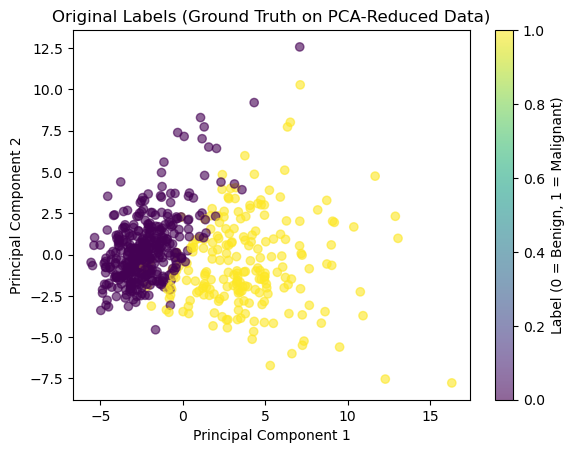

In [12]:
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap="viridis", alpha=0.6)
plt.title("Original Labels (Ground Truth on PCA-Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Label (0 = Benign, 1 = Malignant)")
plt.show()


evaluasting for kmeans with pca

In [13]:
evaluate_clustering(labels,clusters_pca)

Adjusted Rand Index (ARI): 0.6650
Normalized Mutual Information (NMI): 0.5474
Homogeneity: 0.5377
Completeness: 0.5575
V-Measure: 0.5474


evaluating for kmean with og data

In [14]:
evaluate_clustering(labels,clusters_original)

Adjusted Rand Index (ARI): 0.4914
Normalized Mutual Information (NMI): 0.4648
Homogeneity: 0.4223
Completeness: 0.5168
V-Measure: 0.4648


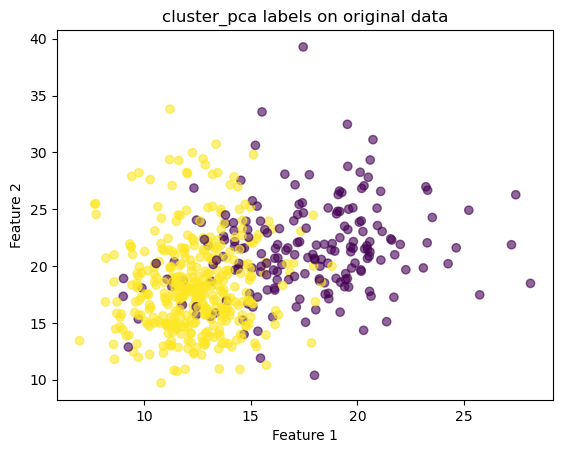

In [16]:
plt.scatter(features[:, 0], features[:, 1], c=clusters_pca, cmap="viridis", alpha=0.6)
plt.title("cluster_pca labels on original data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()
